### Nathan Day - MATH 529L Worksheet 6



---



Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from IPython.display import display, Math

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

def show(*latex_lines): # actual lifesaver for the LaTeX
    for line in latex_lines:
        display(Math(line))

1.1 Separation of Variables

In [ ]:
show(
r"u_t=\kappa u_{xx}",
r"\text{BCs: } u(0,t)=a,\;\;u(L,t)=b",
r"\text{IC: } u(x,0)=f(x)"
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
show(
r"\textbf{Split: } u(x,t)=U(x)+v(x,t)",
r"\text{Let me choose }U \text{, so it satisfies our boundary conditions: } U(0)=a,\;U(L)=b",
r"\Rightarrow v(0,t)=0,\;v(L,t)=0",
r"\text{Here the initial condition for }v: \; v(x,0)=f(x)-U(x)")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

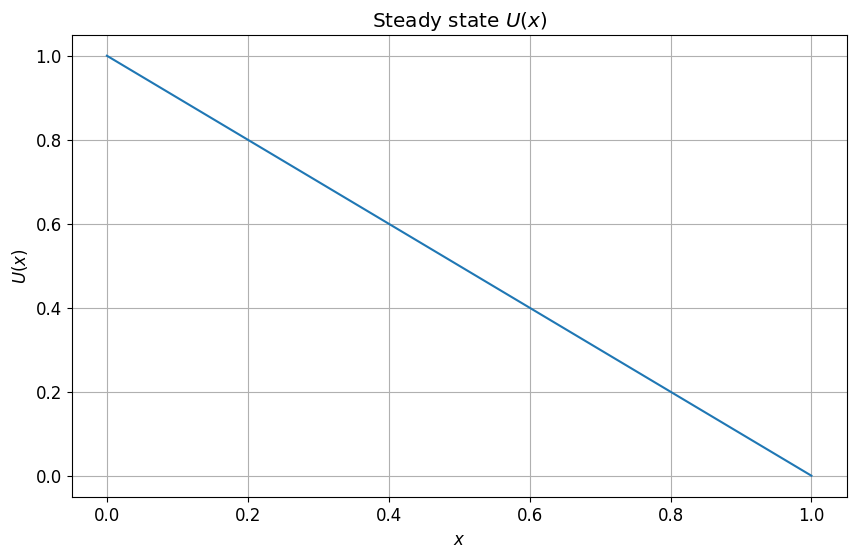

In [ ]:
# Parameters
kappa = 1.0 # set to one as said in class
L = 1.0
a = 1.0
b = 0.0

# Doing the mesh
Nx = 400
x = np.linspace(0, L, Nx)

show(
r"\textbf{Steady state: } U''(x)=0",
r"\Rightarrow U(x)=a+\frac{b-a}{L}x"
)

def U(x):
    return a + (b-a)*x/L

plt.plot(x, U(x))
plt.title("Steady state $U(x)$")
plt.xlabel("$x$")
plt.ylabel("$U(x)$")
plt.grid(True)
plt.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

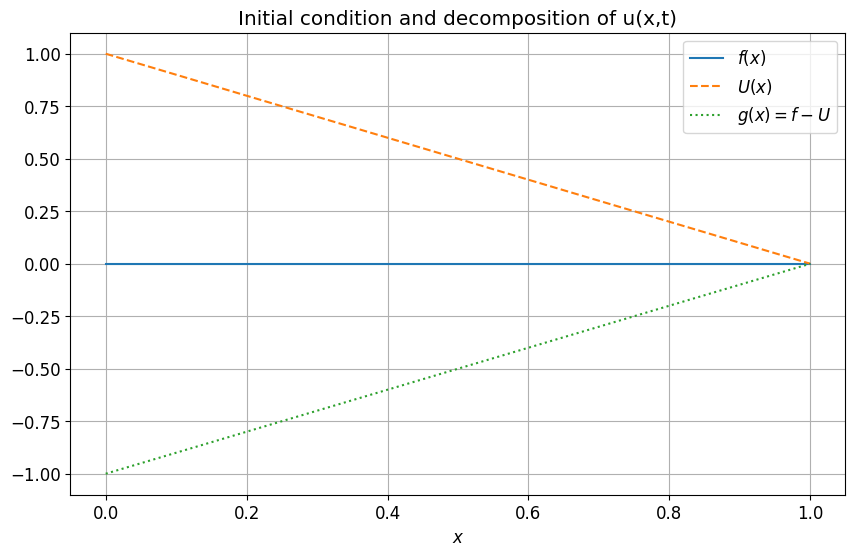

In [ ]:
show(
r"\textbf{If I choose an initial condition } f(x).",
r"\text{Then } g(x)=v(x,0)=f(x)-U(x)."
)

def f(x):
    return np.zeros_like(x)

def g(x):
    return f(x) - U(x)

plt.plot(x, f(x), label="$f(x)$")
plt.plot(x, U(x), "--", label="$U(x)$")
plt.plot(x, g(x), ":", label="$g(x)=f-U$")
plt.title("Initial condition and decomposition of u(x,t)")
plt.xlabel("$x$")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
show(
r"\textbf{The transient solution is:}",
r"v(x,t)=\sum_{n=1}^\infty B_n \sin\!\left(\frac{n\pi x}{L}\right)\exp\!\left(-\kappa\left(\frac{n\pi}{L}\right)^2t\right)",
r"\text{where } B_n=\frac{2}{L}\int_0^L g(x)\sin\!\left(\frac{n\pi x}{L}\right)\,dx"
)

def Bn(n):
    integrand = g(x) * np.sin(n*np.pi*x/L)
    return (2.0/L) * np.trapezoid(integrand, x)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

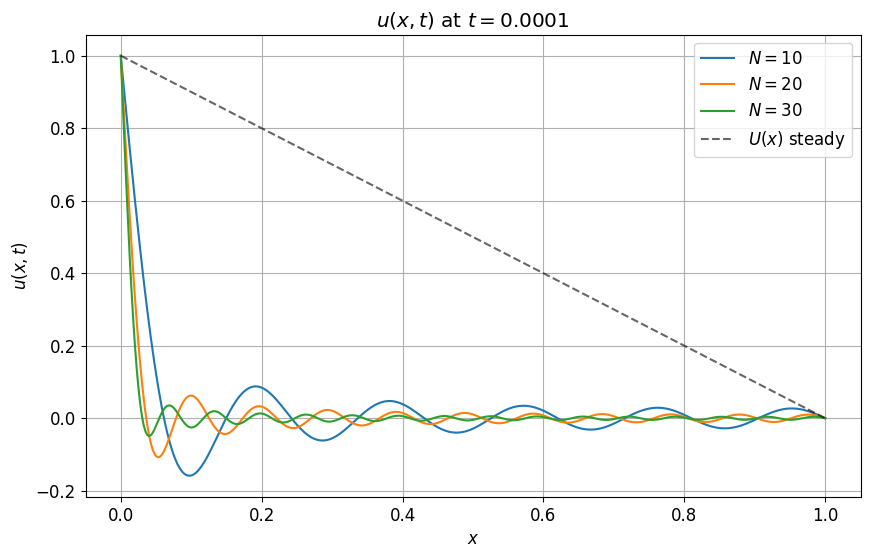

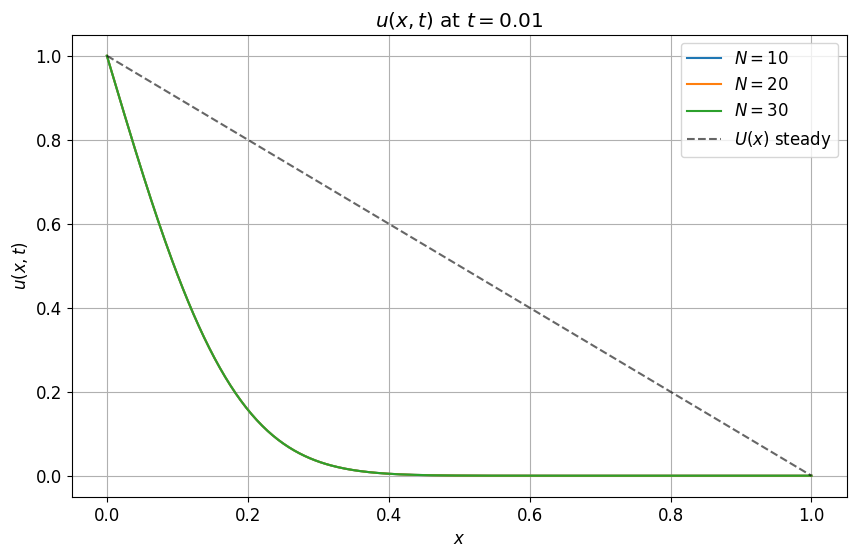

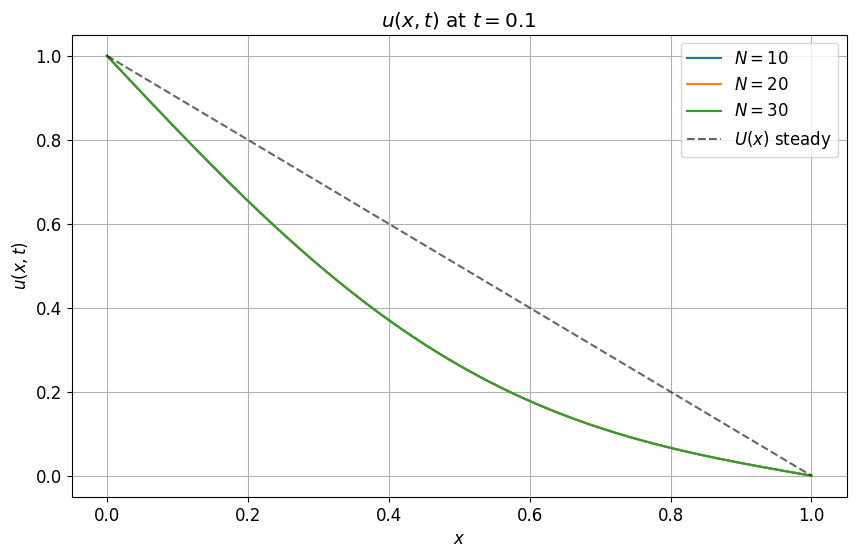

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
def u_xt(xgrid, t, N):
    v = np.zeros_like(xgrid, dtype=float)
    for n in range(1, N+1):
        v += Bn(n) * np.sin(n*np.pi*xgrid/L) * np.exp(-kappa*(n*np.pi/L)**2 * t)
    return U(xgrid) + v

times = [1e-4, 1e-2, 1e-1]

for t in times:
    plt.figure()
    for N in [10, 20, 30]:
        plt.plot(x, u_xt(x, t, N), label=f"$N={N}$")
    plt.plot(x, U(x), "k--", alpha=0.6, label="$U(x)$ steady")
    plt.title(rf"$u(x,t)$ at $t={t}$")
    plt.xlabel("$x$")
    plt.ylabel("$u(x,t)$")
    plt.grid(True)
    plt.legend()
    plt.show()

show(
r"\textbf{Short time: } u(x,t)\approx f(x)",
r"\textbf{As } t\to\infty: \; v(x,t)\to 0 \Rightarrow u(x,t)\to U(x)"
)

1.2

In [ ]:
show(
r"\textbf{This is the heat equation on }\mathbb{R}: \; u_t=\kappa u_{xx},\quad u(x,0)=f(x)",
r"\textbf{This is Green's function: } G(x,t)=\frac{1}{\sqrt{4\pi\kappa t}}\exp\!\left(-\frac{x^2}{4\kappa t}\right)",
r"\textbf{Solution: } u(x,t)=(G(\cdot,t)*f)(x)=\int_{-\infty}^{\infty}G(x-y,t)f(y)\,dy"
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
show(
r"\textbf{For } f(x)=H(x):",
r"u(x,t)=\frac12\left(1+\operatorname{erf}\!\left(\frac{x}{\sqrt{4\kappa t}}\right)\right)"
)

def u_heaviside(xgrid, t): # we said it was a heaviside in class
    return 0.5 * (1.0 + erf(xgrid / np.sqrt(4.0*kappa*t)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

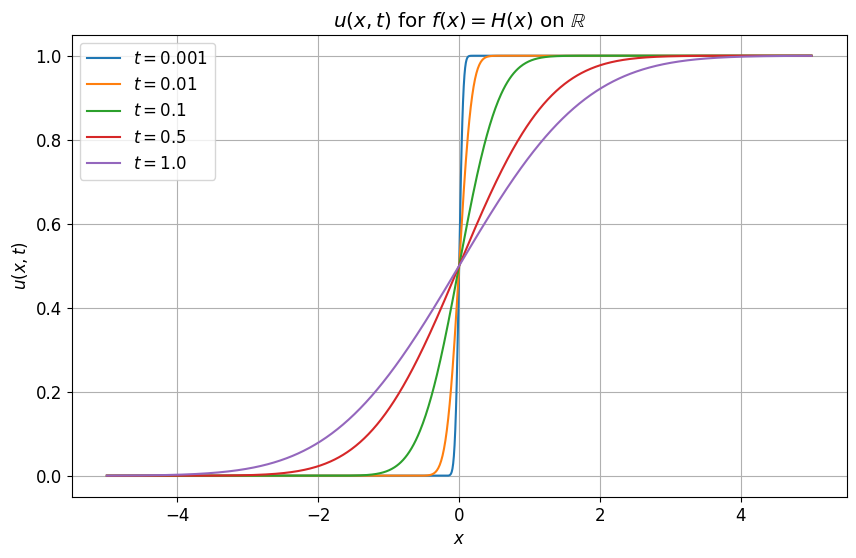

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
xR = np.linspace(-5, 5, 1000)
times = [1e-3, 1e-2, 1e-1, 5e-1, 1.0]

plt.figure()
for t in times:
    plt.plot(xR, u_heaviside(xR, t), label=rf"$t={t}$")
plt.title(r"$u(x,t)$ for $f(x)=H(x)$ on $\mathbb{R}$")
plt.xlabel("$x$")
plt.ylabel("$u(x,t)$")
plt.grid(True)
plt.legend()
plt.show()

show(
r"\textbf{At }x=0:\;\text{the discontinuity becomes immediately smooth for any }t>0.",
r"\textbf{Short time: }\text{sharp transition layer near }x=0.",
r"\textbf{Long time: }\text{transition spreads out (diffusion).}",
r"\textbf{Far field: }\;u(x,t)\to 0\text{ as }x\to-\infty,\;\;u(x,t)\to 1\text{ as }x\to+\infty."
)

show(
r"\textbf{If we used separation of variables:}",
r"\text{On a bounded interval, separation of variables enforces boundary conditions by sine modes,}",
r"\text{and can show Gibbs-type phenomenon like we said in class.}",
r"\text{On }\mathbb{R},\text{ the Gaussian smooths immediately for any }t>0."
)